## Function

In [15]:
import pandas as pd

In [16]:
df_customers_dummy = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E"],
    "age": [22, 35, 47, 63, 29],
    "income": [18000, 42000, 72000, 95000, 25000]
})

df_customers_dummy

,customer,age,income
0,A,22,18000
1,B,35,42000
2,C,47,72000
3,D,63,95000
4,E,29,25000


In [17]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 60:
        return "Adult"
    else:
        return "Old"

print()

In [20]:
df_customers_dummy["age_group"] = df_customers_dummy["age"].apply(age_group)
df_customers_dummy

,customer,age,income,age_group
0,A,22,18000,Young
1,B,35,42000,Adult
2,C,47,72000,Adult
3,D,63,95000,Old
4,E,29,25000,Young


In [ ]:
from utils import age_group


In [29]:
age_group
print()

In [18]:
import pandas as pd
df_scores=pd.DataFrame({
    "student":["Anna","Ben","Chris","Diana","Eva"],
    "score":[95,78,61,43,88]
})
df_scores

,student,score
0,Anna,95
1,Ben,78
2,Chris,61
3,Diana,43
4,Eva,88


In [5]:
df_scores["score_label"]=df_scores["score"].apply(score_label)
df_scores

,student,score,score_label
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Pail
4,Eva,88,Good


In [3]:
def score_label(score):
    if score >=90:
        return"Excellent"
    elif score >=70:
        return"Good"
    elif score>=50:
        return "Pass"
    else:
        return"Pail"
score_label(85)

'Good'

In [6]:
df_scores["score_label"]=[score_label(i) for i in df_scores["score"]]
df_scores

,student,score,score_label
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Pail
4,Eva,88,Good


In [7]:
def classify_price(price, low=5, high=15):
    if price <= low:
        return "Low-range product"
    elif price <= high:
        return "Mid-range product"
    else:
        return "High-range product"

classify_price(9)

'Mid-range product'

In [8]:
df_products_dummy = pd.DataFrame({
    "product": ["Milk", "Bread", "Juice", "Cheese", "Steak", "Apples"],
    "price": [2.5, 1.8, 6.2, 12.0, 24.5, 4.2]
})

df_products_dummy

,product,price
0,Milk,2.5
1,Bread,1.8
2,Juice,6.2
3,Cheese,12.0
4,Steak,24.5
5,Apples,4.2


In [11]:
df_products_dummy.info()


<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   product  6 non-null      str    
 1   price    6 non-null      float64
dtypes: float64(1), str(1)
memory usage: 228.0 bytes


In [12]:
df_products_dummy["price_range"] = df_products_dummy["price"].apply(classify_price)
df_products_dummy

,product,price,price_range
0,Milk,2.5,Low-range product
1,Bread,1.8,Low-range product
2,Juice,6.2,Mid-range product
3,Cheese,12.0,Mid-range product
4,Steak,24.5,High-range product
5,Apples,4.2,Low-range product


## Analytics

In [3]:
df_customers_dummy=pd.DataFrame({
    "customer":["A","B","C","D","E"],
    "age":[22,35,47,63,29],
    "income":[18000,42000,72000,95000,25000]
})
df_customers_dummy

,customer,age,income
0,A,22,18000
1,B,35,42000
2,C,47,72000
3,D,63,95000
4,E,29,25000


In [15]:
def age_group_label(age):
    if age < 30:
        return "Young"
    elif age < 60:
        return "Middle"
    else:
        return "Senior"

df_customers_dummy["age_group"] = df_customers_dummy["age"].apply(age_group_label)
df_customers_dummy

,customer,age,invome,age_group
0,A,22,18000,Young
1,B,35,42000,Middle
2,C,47,72000,Middle
3,D,63,95000,Senior
4,E,29,25000,Young


In [4]:
def income_band(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income < high:
        return "Middle income"
    else:
        return "High income"

df_customers_dummy["income_group"] = df_customers_dummy["income"].apply(income_band)
df_customers_dummy

,customer,age,income,income_group
0,A,22,18000,Low income
1,B,35,42000,Middle income
2,C,47,72000,High income
3,D,63,95000,High income
4,E,29,25000,Low income


In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt

In [4]:
df_instacart = pd.read_csv('../data/processed/instacart.csv')

In [5]:
def price_label(row):
    if row["price"]<=5:
        return "Low-range product"
    elif row["price"]<=15:
        return"Mid-range product"
    elif row ["price"]>15:
        return "Hight-range product"
    else:
        return "Not enough data"

In [23]:
df_instacart["price_range"] = df_instacart.apply(price_label, axis=1)


KeyError: 'price'

In [22]:
df_instacart["price_range"].value_counts(dropna=False)

KeyError: 'price_range'

In [24]:
df_instacart["price_range_loc"] = ""

df_instacart.loc[df_instacart["prices"] > 15, "price_range_loc"] = "High-range product"
df_instacart.loc[
    (df_instacart["prices"] > 5) & (df_instacart["prices"] <= 15),
    "price_range_loc"
] = "Mid-range product"
df_instacart.loc[df_instacart["prices"] <= 5, "price_range_loc"] = "Low-range product"

df_instacart["price_range_loc"].value_counts(dropna=False)

price_range_loc
Mid-range product     936243
Low-range product     430870
High-range product     17505
                          88
Name: count, dtype: int64

In [11]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 60:
        return "Middle"
    else:
        return "Senior"

df_instacart["age_group"] = df_instacart["Age"].apply(age_group)
df_instacart["age_group"].value_counts(dropna=False)

age_group
Middle    652827
Senior    470466
Young     261413
Name: count, dtype: int64

In [13]:
def income_group(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income < high:
        return "Middle income"
    else:
        return "High income"

df_instacart["income_group"] = df_instacart["income"].apply(income_group)
df_instacart["income_group"].value_counts(dropna=False)

income_group
High income      975334
Middle income    398848
Low income        10524
Name: count, dtype: int64

In [14]:
def order_time_band(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df_instacart["order_time_band"] = df_instacart["order_hour_of_day"].apply(order_time_band)
df_instacart["order_time_band"].value_counts(dropna=False)

order_time_band
Afternoon    669307
Morning      434015
Evening      254731
Night         26653
Name: count, dtype: int64

## Lambda

In [19]:
df_scores["pass_flag"] = df_scores["score"].apply(lambda x: "Pass" if x >= 50 else "Fail")
df_scores

,student,score,pass_flag
0,Anna,95,Pass
1,Ben,78,Pass
2,Chris,61,Pass
3,Diana,43,Fail
4,Eva,88,Pass


In [20]:
df_instacart["expensive_product"] = df_instacart["prices"].apply(
    lambda x: "Expensive" if x > 15 else "Not expensive"
)
df_instacart["expensive_product"].value_counts()

expensive_product
Not expensive    1367201
Expensive          17505
Name: count, dtype: int64

In [25]:
price_range_loc_counts = df_instacart["price_range_loc"].value_counts().sort_values()

price_range_loc_counts

price_range_loc
                          88
High-range product     17505
Low-range product     430870
Mid-range product     936243
Name: count, dtype: int64

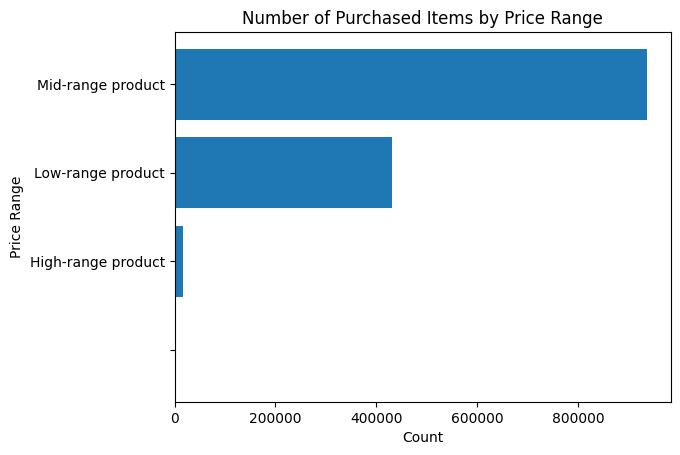

In [28]:
price_range_loc_counts = df_instacart["price_range_loc"].value_counts().sort_values()

plt.figure()
plt.barh(price_range_loc_counts.index, price_range_loc_counts.values)
plt.title("Number of Purchased Items by Price Range")
plt.xlabel("Count")
plt.ylabel("Price Range")
plt.show()

In [33]:
reorder_by_price_range_loc= (
    df_instacart
    .groupby("price_range_loc")["reordered"]
    .mean()
    .sort_values()
)

reorder_by_price_range_loc

price_range_loc
High-range product    0.579092
Low-range product     0.590833
Mid-range product     0.602527
                      0.670455
Name: reordered, dtype: float64

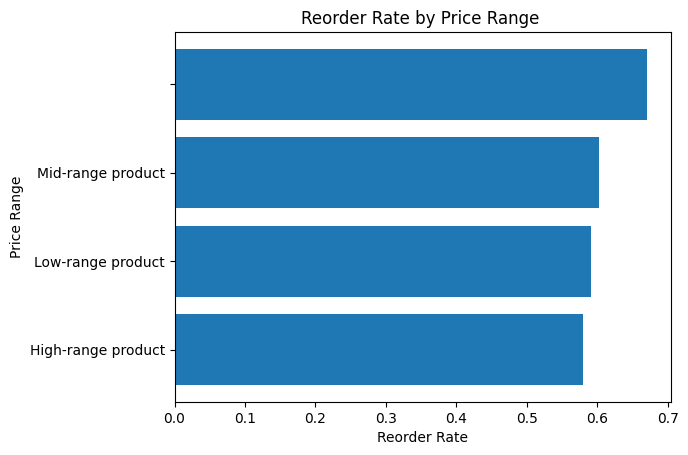

In [34]:
_locreorder_by_price_range_loc = (
    df_instacart
    .groupby("price_range_loc")["reordered"]
    .mean()
    .sort_values()
)

plt.figure()
plt.barh(reorder_by_price_range_loc.index, reorder_by_price_range_loc.values)
plt.title("Reorder Rate by Price Range ")
plt.xlabel("Reorder Rate")
plt.ylabel("Price Range")
plt.show()

In [35]:
df_customers_unique = df_instacart[
    ["First Name", "Surname", "Age", "income", "age_group", "income_group", "region"]
].drop_duplicates()

df_customers_unique.head()

,First Name,Surname,Age,income,age_group,income_group,region
0,Linda,Nguyen,31,40423,Middle,Middle income,South
11,Norma,Chapman,68,64940,Senior,Middle income,West
42,Janet,Lester,75,115242,Senior,High income,West
51,Peter,Villegas,39,89095,Middle,High income,Northeast
60,Anna,Allison,32,88603,Middle,High income,South


In [36]:
age_group_counts = df_customers_unique["age_group"].value_counts().sort_values()
age_group_counts

age_group
Young     24682
Senior    44829
Middle    61698
Name: count, dtype: int64

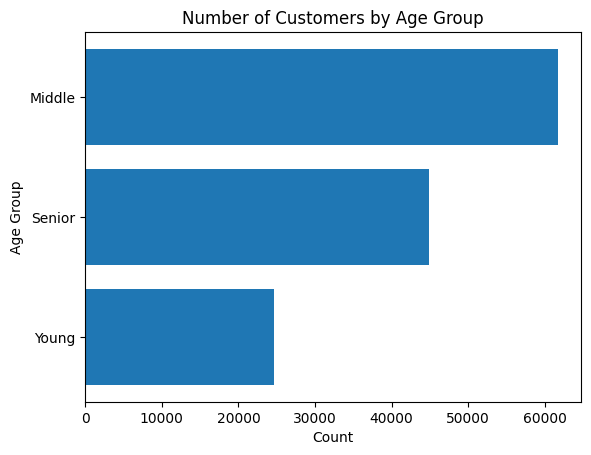

In [37]:
age_group_counts = df_customers_unique["age_group"].value_counts().sort_values()

plt.figure()
plt.barh(age_group_counts.index, age_group_counts.values)
plt.title("Number of Customers by Age Group")
plt.xlabel("Count")
plt.ylabel("Age Group")
plt.show()

In [38]:
avg_income_by_age_group = (
    df_customers_unique
    .groupby("age_group")["income"]
    .mean()
    .sort_values()
)

avg_income_by_age_group

age_group
Young      67597.200065
Middle     94492.928247
Senior    109688.877356
Name: income, dtype: float64

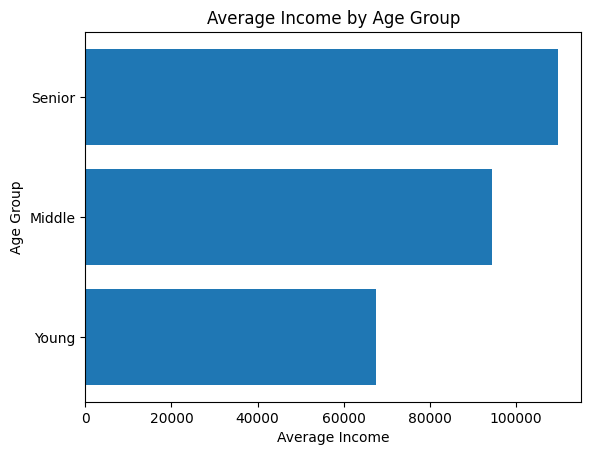

In [39]:
avg_income_by_age_group = (
    df_customers_unique
    .groupby("age_group")["income"]
    .mean()
    .sort_values()
)

plt.figure()
plt.barh(avg_income_by_age_group.index, avg_income_by_age_group.values)
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")
plt.ylabel("Age Group")
plt.show()

In [40]:
orders_time_band = (
    df_instacart[["order_id", "order_time_band"]]
    .drop_duplicates()
    .groupby("order_time_band")
    .size()
    .sort_values()
)

orders_time_band

order_time_band
Night         2507
Evening      24275
Morning      41068
Afternoon    63359
dtype: int64

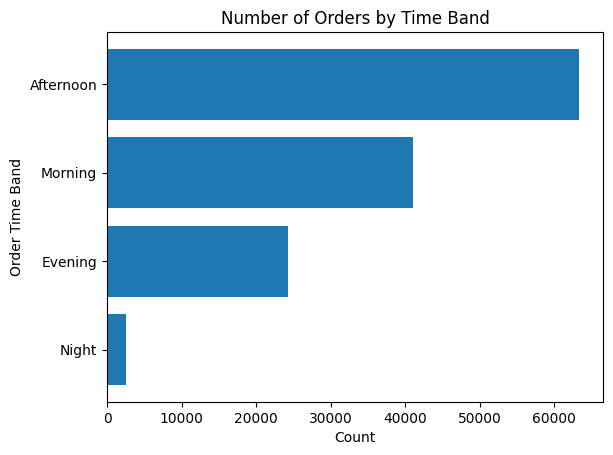

In [41]:
orders_time_band = (
    df_instacart[["order_id", "order_time_band"]]
    .drop_duplicates()
    .groupby("order_time_band")
    .size()
    .sort_values()
)

plt.figure()
plt.barh(orders_time_band.index, orders_time_band.values)
plt.title("Number of Orders by Time Band")
plt.xlabel("Count")
plt.ylabel("Order Time Band")
plt.show()

In [42]:
df_instacart.to_csv("../data/processed/instacart.csv", index = False)

In [2]:
import pandas as pd